## 📓 EDA Notes — Day 16-17 Session

### Dataset Verification
- Shape: (284807, 31) — confirmed, matches expected
- .info() confirms ZERO null values across all 31 columns
- All columns numeric (float64 except Class which is int64)

### Column Meanings
- Time: seconds elapsed since first transaction
- V1-V28: PCA-anonymized features (privacy/legal requirement)
- Amount: transaction value, NOT anonymized
- Class: target variable. 0 = legit, 1 = fraud

### CRITICAL FINDING — Class Imbalance
- Legit: 284,315 (99.83%)
- Fraud: 492 (0.17%)
- Less than 1 in 500 transactions is fraud
- A model predicting "always legit" gets 99.83% accuracy while being USELESS
- LESSON: Accuracy is the WRONG metric for this project
- Will need: Precision, Recall, Confusion Matrix (covered later in modeling phase)

### Amount Column Stats
- Mean: 88.35 | Median: 22.00 | Max: 25,691.16 | Min: 0.00
- Mean >> Median = RIGHT-SKEWED distribution
- Most transactions are small, few extreme outliers drag mean up
- IMPLICATION: Amount likely needs scaling/transformation before modeling
- Fraud pattern theory: fraudsters sometimes test small amounts first

### Habits Learned
- ALWAYS verify shape after loading (catches load/delimiter errors)
- Column names are CASE-SENSITIVE (df['class'] != df['Class'])
- Check .columns.tolist() before referencing column names
- Form a hypothesis BEFORE running code, then compare to reality

### Next Step
- Compare Amount stats: fraud vs non-fraud transactions separately
- Hypothesis pending: does fraud Amount differ from legit Amount?

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('../data/creditcard.csv')
# print(df.columns.tolist())

In [3]:
print(df.shape)

(284807, 31)


In [4]:
print(df.head())

   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28 

In [5]:
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [6]:
print(df['class'].value_counts())

KeyError: 'class'

In [7]:
print(df['Class'].value_counts())

Class
0    284315
1       492
Name: count, dtype: int64


In [8]:
print(df['Amount'].describe())

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


In [9]:
print(df.groupby('Class')['Amount'].describe())

          count        mean         std  min   25%    50%     75%       max
Class                                                                      
0      284315.0   88.291022  250.105092  0.0  5.65  22.00   77.05  25691.16
1         492.0  122.211321  256.683288  0.0  1.00   9.25  105.89   2125.87


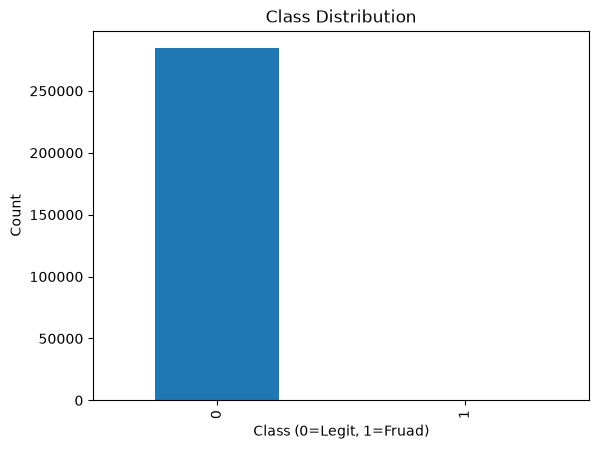

In [10]:
import matplotlib.pyplot as plt

df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class (0=Legit, 1=Fruad)')
plt.ylabel('Count')
plt.show()

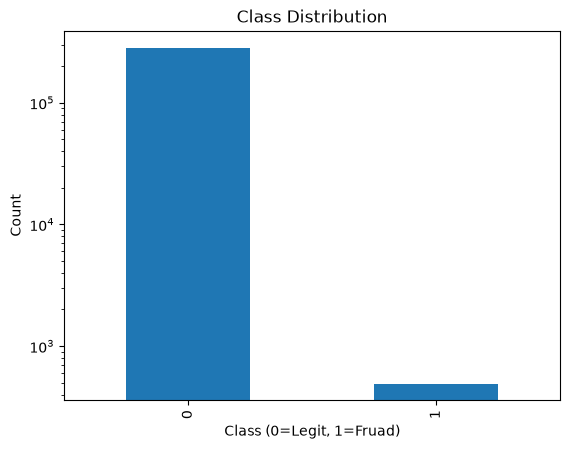

In [11]:
df['Class'].value_counts().plot(kind='bar')
plt.title('Class Distribution')
plt.xlabel('Class (0=Legit, 1=Fruad)')
plt.ylabel('Count')
plt.yscale('log')
plt.show()

In [12]:
corr_matrix = df.corr()
print(corr_matrix['Class'].sort_values(ascending=False))

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64


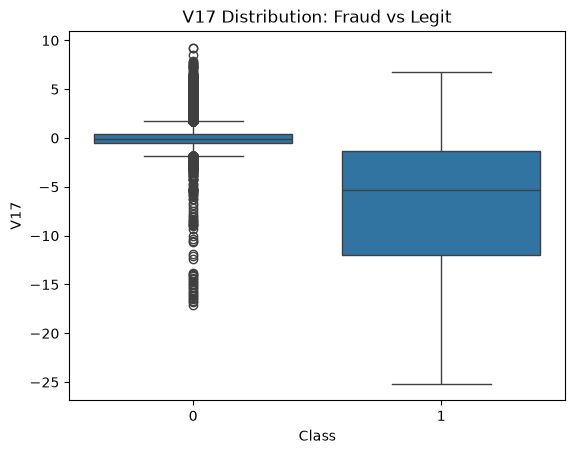

In [13]:
import seaborn as sns

sns.boxplot(x='Class', y='V17', data=df)
plt.title('V17 Distribution: Fraud vs Legit')
plt.show()

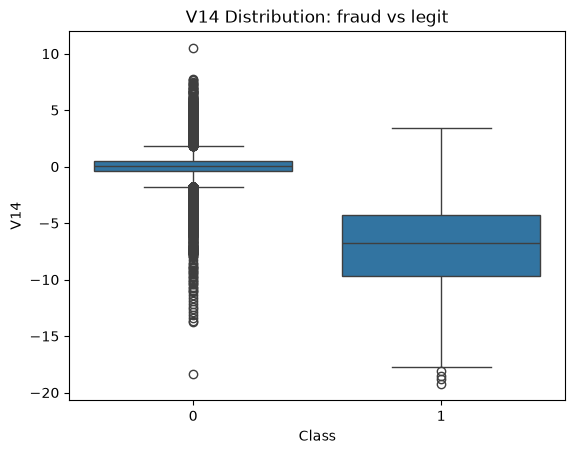

In [14]:
sns.boxplot(x='Class', y='V14', data=df)
plt.title('V14 Distribution: fraud vs legit')
plt.show()

## Correlation & Boxplot — Core Concepts

### Correlation
- Range: -1 to +1
- Measures STRAIGHT-LINE relationship only
- 0 = no LINEAR pattern (curved patterns invisible to this metric)
- Top fraud-correlated features (this dataset): V17 (-0.326), V14 (-0.302), V12 (-0.260)
- No feature alone is strongly correlated (all under 0.33) → fraud needs MULTIPLE features combined

### Boxplot — 5 parts
1. Min (bottom whisker)
2. 25th percentile (bottom of box)
3. Median (line inside box)
4. 75th percentile (top of box)
5. Max (top whisker)
+ Outlier dots = extreme values outside whisker range

### V17 / V14 Boxplot Findings
- Legit (Class 0): tiny box near 0, MANY outlier dots far above/below
  (large sample size = 284,315 → outliers show as individual dots)
- Fraud (Class 1): bigger box, shifted LOWER, fewer outlier dots
  (small sample size = 492 → spread absorbed into box itself)
- IMPORTANT: full ranges of fraud vs legit OVERLAP heavily
  → cannot separate fraud from legit using ONE feature alone

### Big Picture Lesson
- No single feature gives perfect fraud/legit separation
- Need ML model combining MANY features together
- This is WHY fraud detection requires machine learning,
  not simple manual rules

### Full revision summary — all three concepts re-tested and locked

- Class imbalance — 99.83% accuracy from doing nothing is dangerous because it catches zero frauds; you need metrics that measure actual fraud-catching, not overall correctness.
- Correlation — V17's -0.326 is a real, moderate-strength NEGATIVE linear relationship (V17 down → fraud up), and it's your STRONGEST feature even though the number itself isn't close to -1.
- Boxplot overlap — even your strongest feature (V17) has fraud and legit ranges overlapping heavily, meaning no single feature gives certainty — you need multiple features combined, which is why you need a model.

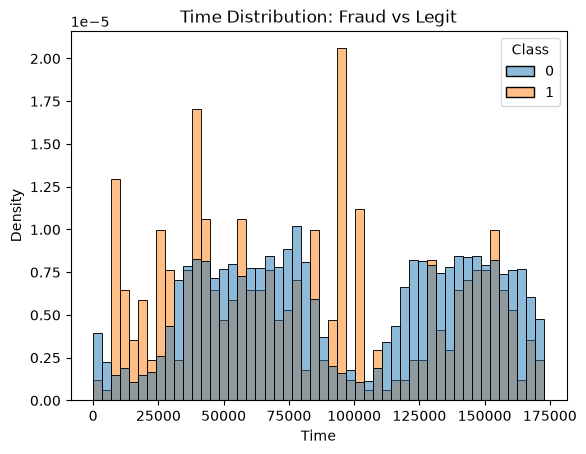

In [15]:
sns.histplot(data=df, x='Time', hue='Class', bins=50, common_norm=False, stat='density')
plt.title('Time Distribution: Fraud vs Legit')
plt.show()

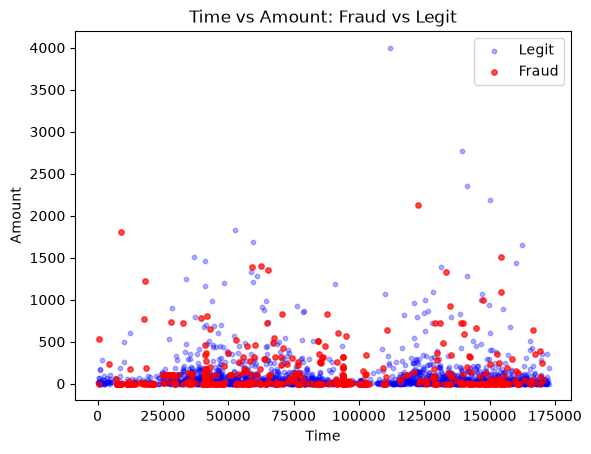

In [16]:
fraud = df[df['Class'] == 1]
legit_sample = df[df['Class'] == 0].sample(n=2000, random_state=42)

plt.scatter(legit_sample['Time'], legit_sample['Amount'], alpha=0.3, s=10, label='Legit', color='blue')
plt.scatter(fraud['Time'], fraud['Amount'], alpha=0.7, s=15, label='Fraud', color='red')
plt.xlabel('Time')
plt.ylabel('Amount')
plt.title('Time vs Amount: Fraud vs Legit')
plt.legend()
plt.show()

## 📓 Preprocessing Notes — Day 16, Session 2

### Why Preprocessing is Needed
Raw EDA data isn't model-ready. Three problems:
1. Scale mismatch (Amount: 0-25,691 vs V1-V28: -5 to +5)
2. No train/test separation yet
3. Severe class imbalance (492 fraud vs 284,315 legit)

---

### 1. Feature Scaling — StandardScaler

**Concept:** Transforms a column to mean=0, std=1 <br>
<span style="color:red">scaled_value = (original_value - mean) / std</span><br>
This is called **standardization** (not normalization — normalization squeezes into a fixed 0-1 range using a different method, e.g. MinMaxScaler).

**Key fact:** Scaling repositions data, does NOT fix skew/shape. Amount stayed right-skewed even after scaling (max=102 std devs away).

**Only Amount and Time needed scaling.** V1-V28 already PCA-transformed, naturally centered near 0.

**Critical rule — fit vs transform:**
- `fit()` — calculates and STORES mean/std inside the scaler object
- `transform()` — applies that stored mean/std
- `fit_transform()` — does both in one call (used during training)
- Calling `fit()` again on the SAME scaler object OVERWRITES the previous mean/std — must use SEPARATE scaler objects for separate columns
- At deployment: use ONLY `.transform()` on new data, reusing the saved training scaler — never re-fit

```python
amount_scaler = StandardScaler()
df['Amount_scaled'] = amount_scaler.fit_transform(df[['Amount']])

time_scaler = StandardScaler()
df['Time_scaled'] = time_scaler.fit_transform(df[['Time']])
```

Note: double brackets `df[['Amount']]` required as sklearn input (needs 2D shape). Single brackets fine for naming new columns on the left side of `=`.

---

### 2. Train/Test Split

**Why needed:** Testing on the same data used for training = no real evaluation. Model could just memorize answers (overfitting) instead of learning generalizable patterns.

**The imbalance risk in random splitting:** With only 492 fraud rows out of 284,807, plain random splitting could by chance create an uneven fraud distribution between train/test (e.g. most fraud landing in one set).

**Fix — stratify parameter:** forces both train and test sets to maintain the SAME class proportion as the original dataset.

```python
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
```

**Verified result:** both train (0.1729% fraud) and test (0.172% fraud) closely matched the original 0.17% ratio.

---

### 3. Handling Class Imbalance — SMOTE

**Problem:** Models trained on imbalanced data have little incentive to learn fraud patterns — predicting "always legit" barely hurts their score.

**Two broad approaches:**
- Resampling (change the data) — oversampling or undersampling
- Class weighting (change the model's penalty system) — not used here, SMOTE chosen instead

**Why NOT undersampling:** throwing away 227,000+ legit rows to match 394 fraud rows = massive information loss, model loses visibility into diverse normal spending patterns.

**Why NOT simple duplication (random oversampling):** copy-pasting the same 394 fraud rows repeatedly causes the model to MEMORIZE those exact rows (overfitting) instead of learning the general pattern.

**SMOTE (Synthetic Minority Oversampling Technique):** generates NEW synthetic fraud examples by interpolating between real fraud points in feature space — not copies, not real duplicates, but plausible new variations.

**CRITICAL RULE:** SMOTE applied ONLY to training data, NEVER to test data. Test set must stay 100% real and untouched, preserving the true real-world imbalance, since that's what a deployed model will actually face.

```python
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)
```

**Verified result:**
- `y_train_resampled`: 227,451 legit / 227,451 fraud (balanced via synthetic data)
- `y_test`: 56,864 legit / 98 fraud (untouched, original imbalance preserved)

---

### Final Pipeline State

<br>
<span style="color:red">X_train_resampled, y_train_resampled -→ balanced, used to TRAIN</span><br>

<span style="color:red">X_test, y_test -→ real imbalance, used to EVALUATE</span><br>
### Next Step
Build first model — Logistic Regression baseline — train on resampled data, evaluate on untouched test data using precision/recall/confusion matrix (NOT accuracy).

In [17]:
from sklearn.preprocessing import StandardScaler

amount_scaler = StandardScaler()
df['Amount_scaled'] = amount_scaler.fit_transform(df[['Amount']])

In [18]:
df[['Amount', 'Amount_scaled']].describe()

,Amount,Amount_scaled
count,284807.000000,2.848070e+05
mean,88.349619,-3.672378e-17
std,250.120109,1.000002e+00
min,0.000000,-3.532294e-01
25%,5.600000,-3.308401e-01
50%,22.000000,-2.652715e-01
75%,77.165000,-4.471707e-02
max,25691.160000,1.023622e+02


In [19]:
time_scaler = StandardScaler()
df['Time_scaled'] = time_scaler.fit_transform(df[['Time']])

In [20]:
df[['Time', 'Time_scaled']].describe()

,Time,Time_scaled
count,284807.000000,2.848070e+05
mean,94813.859575,-5.109395e-17
std,47488.145955,1.000002e+00
min,0.000000,-1.996583e+00
25%,54201.500000,-8.552120e-01
50%,84692.000000,-2.131453e-01
75%,139320.500000,9.372174e-01
max,172792.000000,1.642058e+00


In [21]:
from sklearn.model_selection import train_test_split

X = df.drop(['Class', 'Time', 'Amount'], axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [22]:
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


In [23]:
from imblearn.over_sampling import SMOTE 

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

In [24]:
print(y_train_resampled.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


In [25]:
print(y_test.value_counts())

Class
0    56864
1       98
Name: count, dtype: int64


### MODEL FITTING


In [26]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_resampled, y_train_resampled)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [27]:
X_train.columns.tolist()

['V1',
 'V2',
 'V3',
 'V4',
 'V5',
 'V6',
 'V7',
 'V8',
 'V9',
 'V10',
 'V11',
 'V12',
 'V13',
 'V14',
 'V15',
 'V16',
 'V17',
 'V18',
 'V19',
 'V20',
 'V21',
 'V22',
 'V23',
 'V24',
 'V25',
 'V26',
 'V27',
 'V28',
 'Amount_scaled',
 'Time_scaled']

In [28]:
y_pred = model.predict(X_test)

In [29]:
print(y_pred.shape)
print(pd.Series(y_pred).value_counts())

(56962,)
0    55414
1     1548
Name: count, dtype: int64


In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[55406  1458]
 [    8    90]]


In [31]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.97      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.97     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.97      0.99     56962



## 📓 Model Evaluation Notes — Day 21, Session 2

### The Guard Story (core mental model for everything below)

A security guard stands at a door. 56,962 people walk through (test set).
98 are actual thieves (fraud). 56,864 are honest (legit).

The guard POINTS at 1,548 people he thinks are thieves.
- Of those 1,548 accusations, only 90 were ACTUAL thieves.
- Of the 98 REAL thieves, he caught 90, missed 8.

This guard = your trained Logistic Regression model.
This single story explains every metric below — if a number ever
feels confusing later, come back to this guard.

---

### Confusion Matrix — what it actually is

Four possible outcomes for any prediction:
1. Predicted fraud, actually fraud → True Positive (correct catch)
2. Predicted legit, actually legit → True Negative (correct pass)
3. Predicted fraud, actually legit → False Positive (false alarm)
4. Predicted legit, actually fraud → False Negative (missed fraud — the dangerous one)

```python
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
```

**Actual result:**
<br>
<table border="1" style="border-collapse: collapse; text-align: center;">
    <tr>
        <th></th>
        <th>Predicted Legit</th>
        <th>Predicted Fraud</th>
    </tr>
    <tr>
        <th>Actual Legit</th>
        <td>55406</td>
        <td>1458</td>
    </tr>
    <tr>
        <th>Actual Fraud</th>
        <td>8</td>
        <td>90</td>
    </tr>
</table>
---

### Recall — "out of all REAL thieves, how many did I catch?"
<span style="background-color: lightgreen; padding: 2px;">
Recall = TP / (TP + FN) = 90 / 98 = 0.918 (91.8%)
</span>
Guard caught 92% of real thieves. Strong.

### Precision — "out of all my ACCUSATIONS, how many were correct?"
<span style="background-color: lightgreen; padding: 2px;">
Precision = TP / (TP + FP) = 90 / 1548 = 0.058 (5.8%)
</span>
Only 6% of the guard's accusations were correct. Weak.
1,458 innocent transactions wrongly flagged.

### The Tradeoff (the actual lesson)
A more aggressive guard (casts a wider net) catches more real thieves
(higher recall) but also wrongly accuses more innocent people
(lower precision). Being more cautious flips this the other way.
You can't max both without a genuinely better model — there's always
a tradeoff to manage, not eliminate.

### F1-score — punishes lopsidedness
<span style="background-color: lightgreen; padding: 2px;">
F1 = 2 × (Precision × Recall) / (Precision + Recall)
</span>
Does NOT average the two numbers evenly — drags the score toward
whichever one is WEAKER. A guard with 92% recall but 6% precision
does not get a "50/50" score — he gets dragged down near the bad number.

**My own analogy:** like a DSA OA — no matter how good your dev skills
are, if you fail the OA, you don't get hired. The final outcome doesn't
average your strengths with your weak spot; the weak spot gates the result.

**Actual result:** F1 (class 1, fraud) = 0.11 — confirms severe
precision weakness despite strong recall.

---

### Why accuracy is meaningless here (proven with real numbers)
- Lazy "always predict legit" model: 99.83% accuracy, 0 frauds caught
- Your real, working model: 97.42% accuracy, 90 frauds caught
- The WORSE-accuracy model is the one that's actually useful.
- This is not theoretical — these are this project's own numbers.

### classification_report() — automates the by-hand math above
```python
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))
```
Same precision/recall numbers as calculated by hand — just formatted.
No new concept, just a printout.

---

### Baseline established
First model: Logistic Regression
- Recall: 91.8% | Precision: 5.8% | F1 (fraud class): 0.11
- This is the REFERENCE POINT for every future model attempt.

### Next Step
Try Random Forest (better suited for non-linear patterns, per earlier
correlation discussion) and/or threshold tuning, then compare against
this baseline using the SAME three metrics — not accuracy.

In [32]:
print(X_train_resampled.shape)
print(X_test.shape)
print(y_train_resampled.value_counts())

(454902, 30)
(56962, 30)
Class
0    227451
1    227451
Name: count, dtype: int64


In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_resampled, y_train_resampled)

,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [34]:
y_pred_rf = rf_model.predict(X_test)

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test,y_pred_rf))
print(classification_report(y_test,y_pred_rf))

[[56847    17]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.82      0.82      0.82        98

    accuracy                           1.00     56962
   macro avg       0.91      0.91      0.91     56962
weighted avg       1.00      1.00      1.00     56962



In [40]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X_train_resampled.columns
).sort_values(ascending=False)

feature_importance.head(10)

V14    0.221890
V10    0.109153
V4     0.107627
V17    0.082802
V12    0.081718
V11    0.072230
V3     0.070561
V16    0.034439
V7     0.025885
V2     0.024716
dtype: float64

<function matplotlib.pyplot.show(close=None, block=None)>

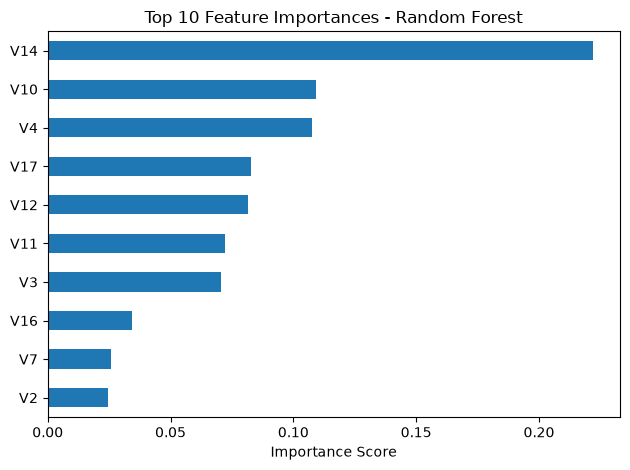

In [41]:
feature_importance.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances - Random Forest')
plt.xlabel('Importance Score')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show

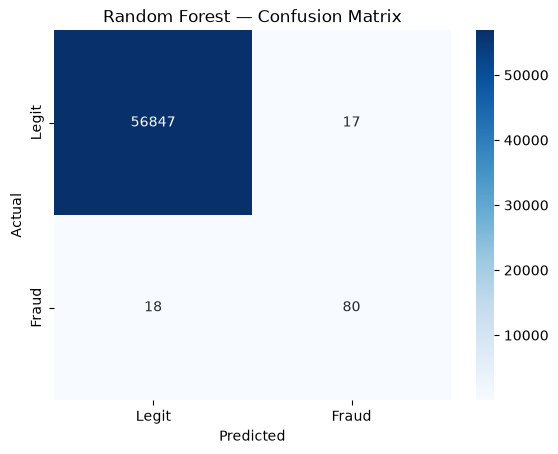

In [42]:
sns.heatmap(confusion_matrix(y_test, y_pred_rf), 
            annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest — Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

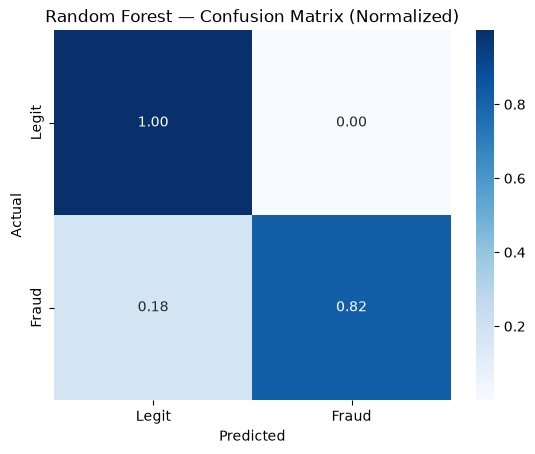

In [43]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_normalized = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis]

sns.heatmap(cm_normalized, 
            annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Legit', 'Fraud'],
            yticklabels=['Legit', 'Fraud'])
plt.title('Random Forest — Confusion Matrix (Normalized)')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [44]:
import joblib

joblib.dump(rf_model, '../models/rf_model.pkl')
joblib.dump(amount_scaler, '../models/amount_scaler.pkl')
joblib.dump(time_scaler, '../models/time_scaler.pkl')

print("Saved.")

Saved.


In [45]:
fraud_sample = df[df['Class'] == 1].iloc[0]
print(fraud_sample)

Time             406.000000
V1                -2.312227
V2                 1.951992
V3                -1.609851
V4                 3.997906
V5                -0.522188
V6                -1.426545
V7                -2.537387
V8                 1.391657
V9                -2.770089
V10               -2.772272
V11                3.202033
V12               -2.899907
V13               -0.595222
V14               -4.289254
V15                0.389724
V16               -1.140747
V17               -2.830056
V18               -0.016822
V19                0.416956
V20                0.126911
V21                0.517232
V22               -0.035049
V23               -0.465211
V24                0.320198
V25                0.044519
V26                0.177840
V27                0.261145
V28               -0.143276
Amount             0.000000
Class              1.000000
Amount_scaled     -0.353229
Time_scaled       -1.988034
Name: 541, dtype: float64


In [46]:
import numpy as np

# Known fraud transaction
time_val = 406.0
amount_val = 0.0
v_vals = [-2.312227, 1.951992, -1.609851, 3.997906, -0.522188, -1.426545, 
          -2.537387, 1.391657, -2.770089, -2.772272, 3.202033, -2.899907,
          -0.595222, -4.289254, 0.389724, -1.140747, -2.830056, -0.016822,
          0.416956, 0.126911, 0.517232, -0.035049, -0.465211, 0.320198,
          0.044519, 0.177840, 0.261145, -0.143276]

time_scaled = time_scaler.transform([[time_val]])[0][0]
amount_scaled = amount_scaler.transform([[amount_val]])[0][0]

features = np.array([v_vals + [amount_scaled, time_scaled]])
print("Feature shape:", features.shape)
print("Prediction:", rf_model.predict(features)[0])

Feature shape: (1, 30)
Prediction: 0


C:\ML_PROJECTS\financial_sentinel\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ML_PROJECTS\financial_sentinel\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
C:\ML_PROJECTS\financial_sentinel\venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [47]:
import pandas as pd

feature_names = list(X_train_resampled.columns)

features_df = pd.DataFrame(
    [v_vals + [amount_scaled, time_scaled]], 
    columns=feature_names
)

print(features_df.columns.tolist())
print("Prediction:", rf_model.predict(features_df)[0])

['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_scaled', 'Time_scaled']
Prediction: 0


In [48]:
# Get all fraud transactions
fraud_df = df[df['Class'] == 1].copy()

# Test each one until we find one the model catches
fraud_df['Amount_scaled'] = amount_scaler.transform(fraud_df[['Amount']])
fraud_df['Time_scaled'] = time_scaler.transform(fraud_df[['Time']])

X_fraud = fraud_df[feature_names]
predictions = rf_model.predict(X_fraud)

# Find first correctly predicted fraud
correct_idx = fraud_df.index[predictions == 1][0]
print(df.loc[correct_idx, ['Time', 'Amount'] + [f'V{i}' for i in range(1,29)]])

Time      4462.000000
Amount     239.930000
V1          -2.303350
V2           1.759247
V3          -0.359745
V4           2.330243
V5          -0.821628
V6          -0.075788
V7           0.562320
V8          -0.399147
V9          -0.238253
V10         -1.525412
V11          2.032912
V12         -6.560124
V13          0.022937
V14         -1.470102
V15         -0.698826
V16         -2.282194
V17         -4.781831
V18         -2.615665
V19         -1.334441
V20         -0.430022
V21         -0.294166
V22         -0.932391
V23          0.172726
V24         -0.087330
V25         -0.156114
V26         -0.542628
V27          0.039566
V28         -0.153029
Name: 4920, dtype: float64
